In [39]:
# Preprocessing data
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df=pd.read_csv(r"D:\Employee_Salary_Prediction\employee_salary_dataset.csv") #reading csv file which is generated before
print(df.head())

   EmployeeID  Age  Gender EducationLevel  YearsOfExperience       JobRole  \
0           1   59  Female     Bachelor's                 14  Data Analyst   
1           2   39    Male            PhD                 10  Data Analyst   
2           3   44    Male     Bachelor's                  1        Tester   
3           4   41    Male     Bachelor's                 11        Tester   
4           5   47    Male     Bachelor's                  9       Manager   

   SkillsScore  Certifications CompanyType  WorkHoursPerWeek   Salary  
0            8               4     Startup                36  1322265  
1            8               4     Startup                33  1373263  
2            8               5     Startup                31   626311  
3           10               5     Startup                58  1271016  
4            3               6         MNC                49  1335551  


In [41]:
print("Dataset Shape:",df.shape) # shape() prints the shape of dataset

Dataset Shape: (2000, 11)


In [42]:
# Handling missing values

print("---------- MISSING VALUES ----------")
print(df.isnull().sum())

---------- MISSING VALUES ----------
EmployeeID           0
Age                  0
Gender               0
EducationLevel       0
YearsOfExperience    0
JobRole              0
SkillsScore          0
Certifications       0
CompanyType          0
WorkHoursPerWeek     0
Salary               0
dtype: int64


In [43]:
# Filling missing numerical values with median if any

numerical_columns=[
    "Age",
    "YearsOfExperience",
    "SkillsScore",
    "Certifications",
    "WorkHoursPerWeek",
    "Salary"
]
for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Filling missing categorical values with mode if any

categorical_columns=[
    "Gender",
    "EducationLevel",
    "JobRole",
    "CompanyType"
]
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\hansi\AppData\Local\Temp\ipykernel_25520\3590636286.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\hansi\AppData\Local\Temp\ipykernel_25520\3590636286.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [44]:
# Removing Duplicate Rows

duplicate_count=df.duplicated().sum()
print("\nDuplicate Rows:", duplicate_count)
df.drop_duplicates(inplace=True)
if duplicate_count>0 :
    print("Duplicates removed successfully!")


Duplicate Rows: 0


In [45]:
# Step 6: Data Validation

print("---------- DATA VALIDATION ----------")

# Check negative salaries
negative_salary=(df["Salary"]<0).sum()
print("\nNegative Salary Records:",negative_salary)

# Check invalid ages
invalid_age=((df["Age"]<18)).sum()
print("\nInvalid Age Records:", invalid_age)

# Check invalid work hours
invalid_workhours = ((df["WorkHoursPerWeek"] <= 0)).sum()
print("\nInvalid WorkHoursPerWeek Records:",invalid_workhours)

# Check final dataset info
print("\n---------- FINAL DATASET INFO ----------\n")
print(df.info())

print("\n---------- CLEANED DATASET ----------\n")
print(df.head())

---------- DATA VALIDATION ----------

Negative Salary Records: 0

Invalid Age Records: 0

Invalid WorkHoursPerWeek Records: 0

---------- FINAL DATASET INFO ----------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   EmployeeID         2000 non-null   int64 
 1   Age                2000 non-null   int64 
 2   Gender             2000 non-null   object
 3   EducationLevel     2000 non-null   object
 4   YearsOfExperience  2000 non-null   int64 
 5   JobRole            2000 non-null   object
 6   SkillsScore        2000 non-null   int64 
 7   Certifications     2000 non-null   int64 
 8   CompanyType        2000 non-null   object
 9   WorkHoursPerWeek   2000 non-null   int64 
 10  Salary             2000 non-null   int64 
dtypes: int64(7), object(4)
memory usage: 172.0+ KB
None

---------- CLEANED DATASET ----------

   EmployeeID  

In [46]:
# Encoding categorical data

from sklearn.preprocessing import LabelEncoder

print("---------- ENCODING ----------")
label_encoders={}
for col in categorical_columns:
    encoder=LabelEncoder()  # Model cannot understand text so we convert it into numerical values
    df[col]=encoder.fit_transform(df[col])
    label_encoders[col]=encoder
    print(f"{col} Encoded") 

---------- ENCODING ----------
Gender Encoded
EducationLevel Encoded
JobRole Encoded
CompanyType Encoded


In [47]:
# Feature scaling

from sklearn.preprocessing import StandardScaler
print("---------- FEATURE SCALING ----------")
scaler=StandardScaler()
scaling_columns=[
    "Age",
    "YearsOfExperience",
    "SkillsScore",
    "Certifications",
    "WorkHoursPerWeek"
]
df[scaling_columns]=scaler.fit_transform(df[scaling_columns])
print("Feature scaling completed!")

---------- FEATURE SCALING ----------
Feature scaling completed!


In [48]:
df.head()

,EmployeeID,Age,Gender,EducationLevel,YearsOfExperience,JobRole,SkillsScore,Certifications,CompanyType,WorkHoursPerWeek,Salary
0,1,1.693837,0,0,0.783078,0,0.876972,-0.303132,2,-1.046555,1322265
1,2,-0.109604,1,2,0.084603,0,0.876972,-0.303132,2,-1.394017,1373263
2,3,0.341256,1,0,-1.486967,4,0.876972,0.016628,2,-1.625658,626311
3,4,0.070740,1,0,0.259222,4,1.563850,0.016628,2,1.501498,1271016
4,5,0.611772,1,0,-0.090016,3,-0.840224,0.336387,0,0.459113,1335551


In [49]:
# Saving preprocessed data

output_path = r"D:\Employee_Salary_Prediction\preprocessed_employee_salary_dataset.csv"

df.to_csv(output_path, index=False)

print("Preprocessed dataset saved successfully!")
print("Location:", output_path)

Preprocessed dataset saved successfully!
Location: D:\Employee_Salary_Prediction\preprocessed_employee_salary_dataset.csv


In [50]:
# Exploratory Data Analysis (EDA)

# Basic Dataset Information

print("---------- FIRST 5 RECORDS ----------")
print(df.head())

print("\n---------- DATASET SHAPE ----------")
print(df.shape)

print("\n---------- COLUMN NAMES ----------")
print(df.columns)

print("\n---------- DATA TYPES ----------")
print(df.dtypes)

# STATISTICAL SUMMARY 
print("\n Describe() :")
print(df.describe())

# Missing Values Analysis
print("\n---------- MISSING VALUES ----------")
print(df.isnull().sum())

# Duplicate Records Analysis
print("\n---------- DUPLICATE RECORDS ----------")
print(df.duplicated().sum())

---------- FIRST 5 RECORDS ----------
   EmployeeID       Age  Gender  EducationLevel  YearsOfExperience  JobRole  \
0           1  1.693837       0               0           0.783078        0   
1           2 -0.109604       1               2           0.084603        0   
2           3  0.341256       1               0          -1.486967        4   
3           4  0.070740       1               0           0.259222        4   
4           5  0.611772       1               0          -0.090016        3   

   SkillsScore  Certifications  CompanyType  WorkHoursPerWeek   Salary  
0     0.876972       -0.303132            2         -1.046555  1322265  
1     0.876972       -0.303132            2         -1.394017  1373263  
2     0.876972        0.016628            2         -1.625658   626311  
3     1.563850        0.016628            2          1.501498  1271016  
4    -0.840224        0.336387            0          0.459113  1335551  

---------- DATASET SHAPE ----------
(2000, 11)



In [51]:
# Relationship Between Experience and Salary

print("---------- EXPERIENCE VS SALARY ----------")
experience_salary=df[["YearsOfExperience", "Salary"]].corr()
print(experience_salary)
average_salary_experience=df.groupby("YearsOfExperience")["Salary"].mean()
print("\nAverage Salary Based on Experience:\n")
print(average_salary_experience)

---------- EXPERIENCE VS SALARY ----------
                   YearsOfExperience    Salary
YearsOfExperience           1.000000  0.903038
Salary                      0.903038  1.000000

Average Salary Based on Experience:

YearsOfExperience
-1.661586    8.286734e+05
-1.486967    8.501426e+05
-1.312348    9.059922e+05
-1.137729    9.754102e+05
-0.963110    1.044644e+06
-0.788491    1.089103e+06
-0.613873    1.128625e+06
-0.439254    1.205934e+06
-0.264635    1.216557e+06
-0.090016    1.256370e+06
 0.084603    1.326682e+06
 0.259222    1.385997e+06
 0.433841    1.421218e+06
 0.608459    1.473493e+06
 0.783078    1.527513e+06
 0.957697    1.592601e+06
 1.132316    1.629655e+06
 1.306935    1.695486e+06
 1.481554    1.738347e+06
 1.656173    1.776949e+06
Name: Salary, dtype: float64


In [52]:
# Impact of Education Level on Salary

print("---------- EDUCATION LEVEL VS SALARY ----------")
education_salary=df.groupby("EducationLevel")["Salary"].agg(["mean", "min", "max"])
print(education_salary)

---------- EDUCATION LEVEL VS SALARY ----------
                        mean     min      max
EducationLevel                               
0               1.182978e+06  478731  1871350
1               1.313189e+06  653265  1985386
2               1.420206e+06  730424  2151707


In [53]:
# Salary Distribution Across Job Roles

print("---------- JOB ROLE VS SALARY ----------")
jobrole_salary=df.groupby("JobRole")["Salary"].agg(["mean", "min", "max"])
print(jobrole_salary)

---------- JOB ROLE VS SALARY ----------
                 mean     min      max
JobRole                               
0        1.310968e+06  616418  2069613
1        1.230419e+06  564055  1950925
2        1.288868e+06  591745  2063856
3        1.446968e+06  761985  2151707
4        1.243034e+06  478731  1895405


In [54]:
# Top Correlations with Salary

print("---------- FEATURES MOST RELATED TO SALARY ----------")
salary_correlation=correlation_matrix["Salary"].sort_values(ascending=False)
print(salary_correlation)

---------- FEATURES MOST RELATED TO SALARY ----------
Salary               1.000000
YearsOfExperience    0.729707
EducationLevel       0.360636
SkillsScore          0.270804
Certifications       0.188885
JobRole              0.054683
EmployeeID           0.024226
Age                  0.005021
WorkHoursPerWeek    -0.001992
Gender              -0.013728
CompanyType         -0.183072
Name: Salary, dtype: float64


In [55]:
# Skills Score Impact on Salary

print("---------- SKILLS SCORE VS SALARY ----------")
skills_salary=df.groupby("SkillsScore")["Salary"].mean()
print(skills_salary)

---------- SKILLS SCORE VS SALARY ----------
SkillsScore
-1.527102    1.250903e+06
-1.183663    1.273382e+06
-0.840224    1.266192e+06
-0.496785    1.253193e+06
-0.153346    1.311305e+06
 0.190094    1.291890e+06
 0.533533    1.320430e+06
 0.876972    1.375293e+06
 1.220411    1.342562e+06
 1.563850    1.363863e+06
Name: Salary, dtype: float64


In [56]:
# Certifications Impact on Salary

print("---------- CERTIFICATIONS VS SALARY ----------")
certification_salary=df.groupby("Certifications")["Salary"].mean()
print(certification_salary)

---------- CERTIFICATIONS VS SALARY ----------
Certifications
-1.582172    1.285651e+06
-1.262412    1.251507e+06
-0.942652    1.280223e+06
-0.622892    1.285266e+06
-0.303132    1.274480e+06
 0.016628    1.340564e+06
 0.336387    1.303656e+06
 0.656147    1.351142e+06
 0.975907    1.311683e+06
 1.295667    1.326800e+06
 1.615427    1.343029e+06
Name: Salary, dtype: float64


In [57]:
# Company Type Impact on Salary

print("\n---------- COMPANY TYPE VS SALARY ----------")

company_salary=df.groupby("CompanyType")["Salary"].agg(["mean", "min", "max"])
print(company_salary)


---------- COMPANY TYPE VS SALARY ----------
                     mean     min      max
CompanyType                               
0            1.382450e+06  665415  2151707
1            1.285145e+06  564055  1991044
2            1.234945e+06  478731  1942475


In [58]:
#Correlation Matrix

print("---------- CORRELATION MATRIX ----------")
correlation_matrix=df.corr(numeric_only=True)
print(correlation_matrix)

---------- CORRELATION MATRIX ----------
                   EmployeeID       Age    Gender  EducationLevel  \
EmployeeID           1.000000 -0.026205 -0.006782       -0.005192   
Age                 -0.026205  1.000000 -0.033827       -0.003655   
Gender              -0.006782 -0.033827  1.000000        0.006954   
EducationLevel      -0.005192 -0.003655  0.006954        1.000000   
YearsOfExperience    0.037459  0.006147  0.003849        0.045869   
JobRole             -0.016866 -0.022184 -0.007693        0.005651   
SkillsScore         -0.009099 -0.005798  0.010344        0.027248   
Certifications      -0.004151 -0.003440  0.008817       -0.005198   
CompanyType         -0.011754 -0.003331 -0.036664        0.030482   
WorkHoursPerWeek    -0.006291  0.014765 -0.017043       -0.012899   
Salary               0.038444  0.006443  0.011572        0.303309   

                   YearsOfExperience   JobRole  SkillsScore  Certifications  \
EmployeeID                  0.037459 -0.016866    -

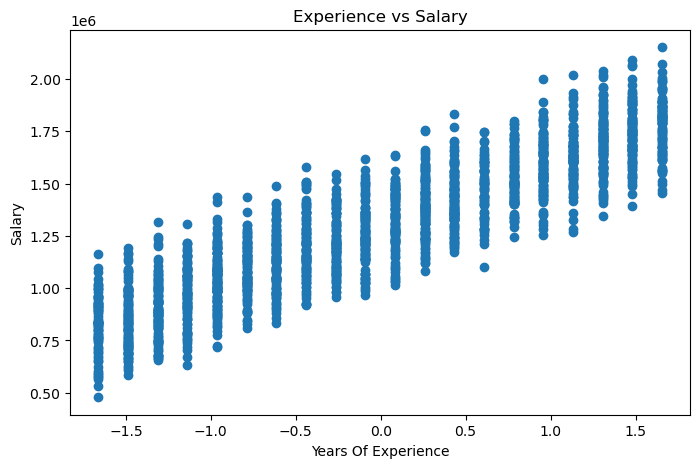

In [59]:
import matplotlib.pyplot as plt
# Experience vs Salary

plt.figure(figsize=(8,5))
plt.scatter(
    df["YearsOfExperience"],
    df["Salary"]
)
plt.title("Experience vs Salary")
plt.xlabel("Years Of Experience")
plt.ylabel("Salary")
plt.show()

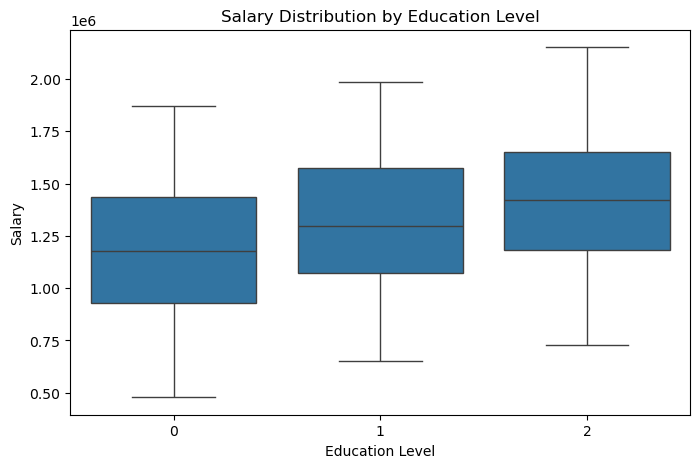

In [60]:
# Salary Distribution by Education Level

plt.figure(figsize=(8,5))
sns.boxplot(
    x="EducationLevel",
    y="Salary",
    data=df
)
plt.title("Salary Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Salary")
plt.show()

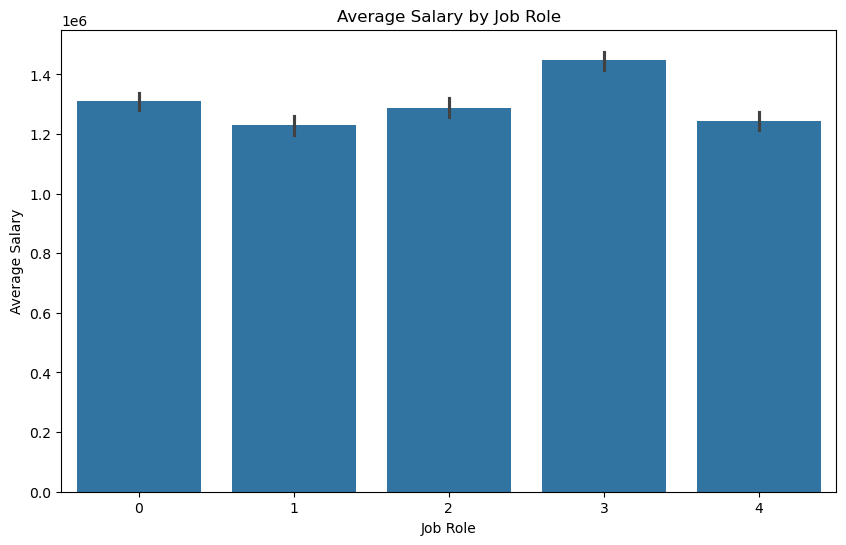

In [61]:
# Average Salary by Job Role

plt.figure(figsize=(10,6))
sns.barplot(
    x="JobRole",
    y="Salary",
    data=df
)
plt.title("Average Salary by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Average Salary")
plt.show()

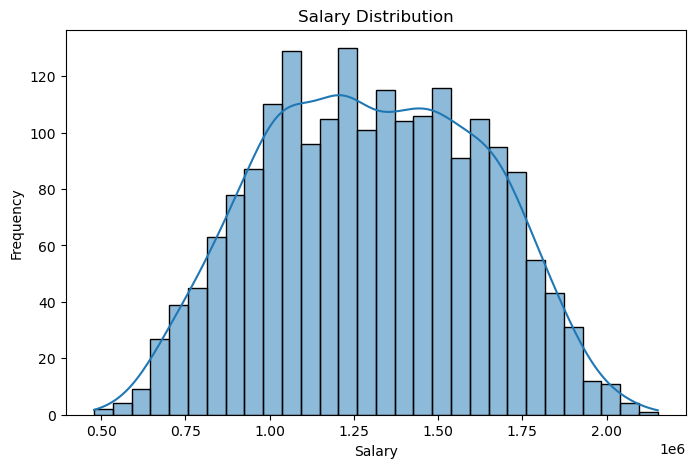

In [62]:
# Salary Distribution Histogram

plt.figure(figsize=(8,5))
sns.histplot(
    df["Salary"],
    bins=30,
    kde=True
)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

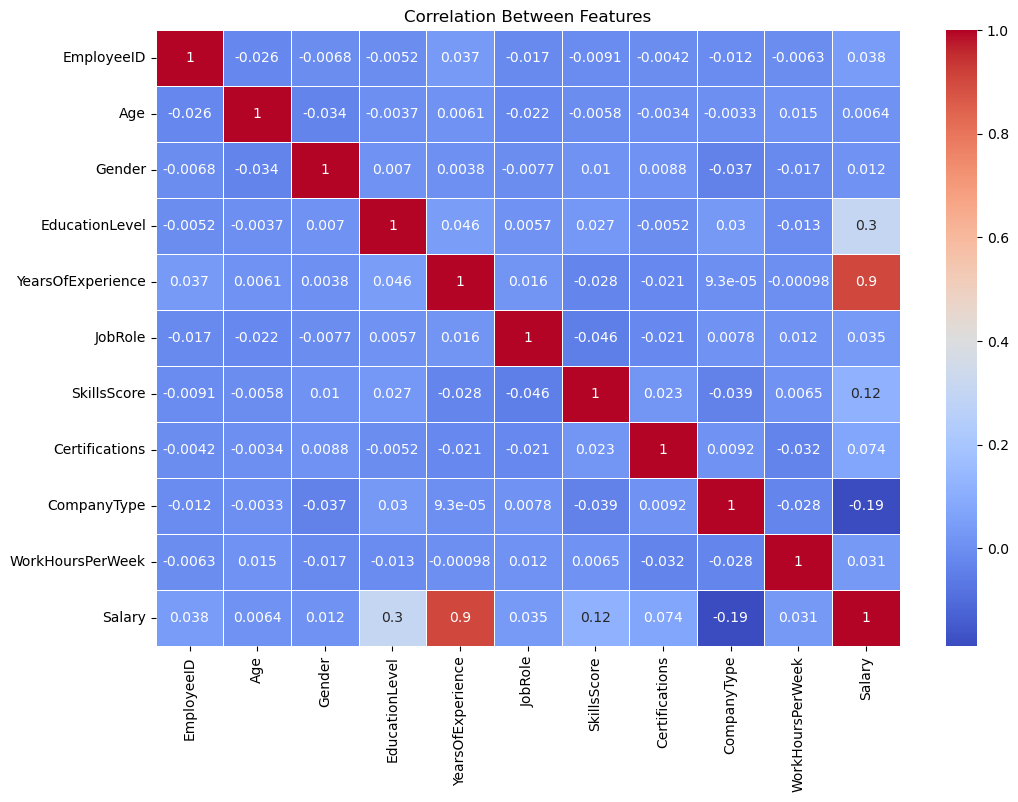

In [63]:
# correlation between features

plt.figure(figsize=(12,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Between Features")
plt.show()

In [64]:
# Machine Learning Regression Model

# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [65]:
# Encode Categorical Columns

label_encoders={}
categorical_columns=[
    "Gender",
    "EducationLevel",
    "JobRole",
    "CompanyType"
]
for col in categorical_columns:
    encoder=LabelEncoder()
    df[col]=encoder.fit_transform(df[col])
    label_encoders[col]=encoder

In [66]:
# Features and Target Variable

X=df.drop(["EmployeeID","Salary"],axis=1)
y=df["Salary"]

In [67]:
# Split Dataset into Training and Testing

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Data Shape:",X_train.shape)
print("Testing Data Shape:",X_test.shape)

Training Data Shape: (1600, 9)
Testing Data Shape: (400, 9)


In [68]:
# Create Models

linear_model=LinearRegression()
decision_tree_model=DecisionTreeRegressor(random_state=42)
random_forest_model = RandomForestRegressor(n_estimators=100,random_state=42)

In [69]:
# Train Models

linear_model.fit(X_train,y_train)
decision_tree_model.fit(X_train,y_train)
random_forest_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
# Predictions

linear_pred=linear_model.predict(X_test)
decision_tree_pred=decision_tree_model.predict(X_test)
random_forest_pred=random_forest_model.predict(X_test)

In [71]:
# Evaluation Function

def evaluate_model(model_name,y_test,predictions):
    mae=mean_absolute_error(y_test,predictions)
    rmse = np.sqrt(mean_squared_error(y_test,predictions))
    r2 = r2_score(y_test,predictions)
    print(f"\n========== {model_name} ==========")
    print("MAE :",mae)
    print("RMSE:",rmse)
    print("R2 Score:",r2)

# Evaluate Models

evaluate_model("Linear Regression",y_test,linear_pred)
evaluate_model("Decision Tree Regressor",y_test,decision_tree_pred)
evaluate_model("Random Forest Regressor",y_test,random_forest_pred)


========== Linear Regression ==========
MAE : 57209.66324747587
RMSE: 71249.34381294808
R2 Score: 0.9518296070226068

========== Decision Tree Regressor ==========
MAE : 87144.235
RMSE: 110644.59586766992
R2 Score: 0.883834045532631

========== Random Forest Regressor ==========
MAE : 53720.719500000014
RMSE: 67102.46037423675
R2 Score: 0.9572736946467517


In [74]:
# =========================================
# Employee Salary Prediction System
# Console-Based Prediction System
# With Proper Error Handling
# =========================================

#valid inputs

valid_genders = ["Male", "Female"]

valid_education = [
    "Bachelor's",
    "Master's",
    "PhD"
]

valid_job_roles = [
    "Developer",
    "Data Analyst",
    "Manager",
    "Designer",
    "Tester"
]

valid_company_types = [
    "Startup",
    "MNC",
    "Medium Scale"
]

# =========================================
# Console Interface
# =========================================

print("\n------------------------------------")
print(" EMPLOYEE SALARY PREDICTION SYSTEM ")
print("-------------------------------------\n")

try:

    # =========================================
    # Age Validation
    # =========================================

    age = int(input("Enter Age: "))

    if age < 18 or age > 65:
        raise ValueError("Age must be between 18 and 65.")

    # =========================================
    # Gender Validation
    # =========================================

    gender = input("Enter Gender (Male/Female): ").strip()

    if gender not in valid_genders:
        raise ValueError("Invalid Gender Entered.")

    # =========================================
    # Education Validation
    # =========================================

    education = input("Enter Education Level (Bachelor's/Master's/PhD): ").strip()

    if education not in valid_education:
        raise ValueError("Invalid Education Level Entered.")

    # =========================================
    # Experience Validation
    # =========================================

    experience = int(input("Enter Years of Experience: "))

    if experience < 0 or experience > 40:
        raise ValueError("Experience must be between 0 and 40.")

    # =========================================
    # Skills Score Validation
    # =========================================

    skills_score = int(input("Enter Skills Score (1-10): "))

    if skills_score < 1 or skills_score > 10:
        raise ValueError("Skills Score must be between 1 and 10.")

    # =========================================
    # Certifications Validation
    # =========================================

    certifications = int(input("Enter Number of Certifications: "))

    if certifications < 0:
        raise ValueError("Certifications cannot be negative.")

    # =========================================
    # Job Role Validation
    # =========================================

    job_role = input("Enter Job Role (Developer/Data Analyst/Manager/Designer/Tester): ").strip()

    if job_role not in valid_job_roles:
        raise ValueError("Invalid Job Role Entered.")

    # =========================================
    # Company Type Validation
    # =========================================

    company_type = input("Enter Company Type (Startup/MNC/Medium Scale): ").strip()

    if company_type not in valid_company_types:
        raise ValueError("Invalid Company Type Entered.")

    # =========================================
    # Work Hours Validation
    # =========================================

    work_hours = int(input("Enter Work Hours Per Week: "))

    if work_hours < 20 or work_hours > 100:
        raise ValueError("Work hours must be between 20 and 100.")

    # =========================================
    # Encode User Inputs
    # =========================================

    gender_encoded = label_encoders["Gender"].transform([gender])[0]
    education_encoded = label_encoders["EducationLevel"].transform([education])[0]
    job_role_encoded = label_encoders["JobRole"].transform([job_role])[0]
    company_encoded = label_encoders["CompanyType"].transform([company_type])[0]

    # =========================================
    # Create Input DataFrame
    # =========================================

    input_df = pd.DataFrame([{
        "Age": age,
        "Gender": gender_encoded,
        "EducationLevel": education_encoded,
        "YearsOfExperience": experience,
        "JobRole": job_role_encoded,
        "SkillsScore": skills_score,
        "Certifications": certifications,
        "CompanyType": company_encoded,
        "WorkHoursPerWeek": work_hours
    }])

    # =========================================
    # Predict Salary
    # =========================================

    predicted_salary = model.predict(input_df)

    # =========================================
    # Display Result
    # =========================================

    print("\n------------------------------------")
    print(" PREDICTED EMPLOYEE SALARY ")
    print("------------------------------------\n")

    print(f"Estimated Annual Salary: ₹{predicted_salary[0]:,.2f}")

# =========================================
# Error Handling
# =========================================

except ValueError as ve:

    print("\nINPUT ERROR:", ve)

except Exception as e:

    print("\nSYSTEM ERROR:", e)

finally:

    print("\nProgram Executed Successfully.")


------------------------------------
 EMPLOYEE SALARY PREDICTION SYSTEM 
-------------------------------------



Enter Age:  25
Enter Gender (Male/Female):  Male
Enter Education Level (Bachelor's/Master's/PhD):  Master's
Enter Years of Experience:  8
Enter Skills Score (1-10):  8
Enter Number of Certifications:  4
Enter Job Role (Developer/Data Analyst/Manager/Designer/Tester):  Developer
Enter Company Type (Startup/MNC/Medium Scale):  Startup
Enter Work Hours Per Week:  50



------------------------------------
 PREDICTED EMPLOYEE SALARY 
------------------------------------

Estimated Annual Salary: ₹1,193,949.64

Program Executed Successfully.
